# Isolation Forest - TSI
## Notebook independiente para el primer algoritmo

### Objetivo
Diagnosticar la calidad de los datos y aplicar Isolation Forest con visualizaciones simples y legibles.

### Enfoque
- Revisar calidad, nulos y variabilidad
- Seleccionar solo variables útiles
- Entrenar Isolation Forest
- Guardar el dataset filtrado
- Mostrar resultados sencillos

## 1. Importación y Configuración

In [27]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Librerías cargadas y estilo configurado')

Librerías cargadas y estilo configurado


## 2. Carga de Datos

In [28]:
DATA_CANDIDATES = [
    Path('../../data/00_raw/traffic_data.csv'),
    Path('../../data/02_clean/traffic_data.csv'),
    Path('../../data/raw/traffic_data.csv')
]

data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('No se encontró traffic_data.csv en las rutas esperadas')

df = pd.read_csv(data_path)
print(f'Dataset cargado desde: {data_path}')
print(f'Registros: {len(df)} | Columnas: {len(df.columns)}')
print(df.head())

Dataset cargado desde: ..\..\data\00_raw\traffic_data.csv
Registros: 310 | Columnas: 9
                    timestamp       avenida  velocidad  densidad  detenciones  \
0  2026-03-17 22:31:30.850956  Lopez Mateos       25.0         3          2.0   
1  2026-03-17 22:31:30.859960  Lopez Mateos       20.0         3          2.0   
2  2026-03-17 22:31:30.882579  Lopez Mateos       15.0         3          2.0   
3  2026-03-17 22:42:42.487827  Lopez Mateos       25.0         3          2.0   
4  2026-03-17 22:42:42.493310  Lopez Mateos       20.0         3          2.0   

  descripcion  latitud  longitud horario  
0         NaN      NaN       NaN     NaN  
1         NaN      NaN       NaN     NaN  
2         NaN      NaN       NaN     NaN  
3         NaN      NaN       NaN     NaN  
4         NaN      NaN       NaN     NaN  


## 3. Diagnóstico de Calidad

Resumen de calidad de datos:
             Nulos  Unicos  % Nulos
timestamp        0     310     0.00
avenida          0       9     0.00
velocidad        0      60     0.00
densidad         0       3     0.00
detenciones      0      20     0.00
descripcion     18     274     5.81
latitud         68       6    21.94
longitud        68       6    21.94
horario         68       5    21.94


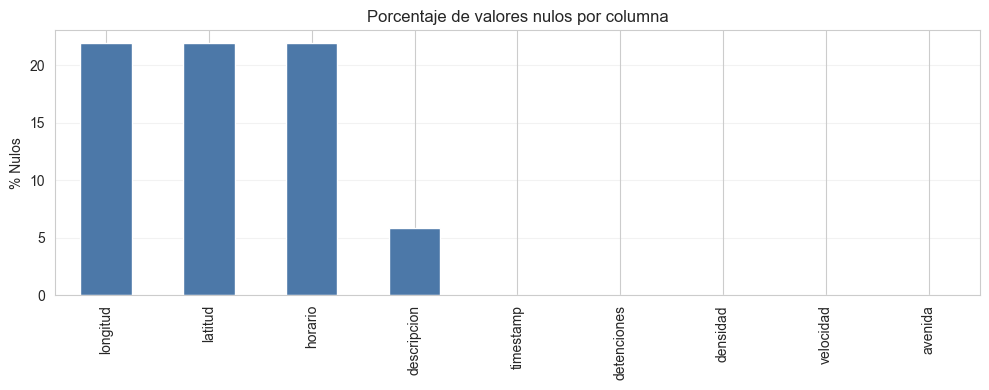


Desviación estándar de variables numéricas:
velocidad      15.547
densidad        0.712
detenciones     6.018
latitud         0.025
longitud        0.055
dtype: float64


In [29]:
quality_report = pd.DataFrame({
    'Nulos': df.isna().sum(),
    'Unicos': df.nunique(dropna=True)
})
quality_report['% Nulos'] = (quality_report['Nulos'] / len(df) * 100).round(2)

print('Resumen de calidad de datos:')
print(quality_report)

fig, ax = plt.subplots(figsize=(10, 4))
quality_report.sort_values('% Nulos', ascending=False)['% Nulos'].plot(kind='bar', ax=ax, color='#4C78A8')
ax.set_title('Porcentaje de valores nulos por columna')
ax.set_ylabel('% Nulos')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('../../data/03_algorithm_output/10_isolation_forest_quality.png', dpi=300, bbox_inches='tight')
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
dispersion = df[numeric_cols].std(numeric_only=True).round(3)
print()
print('Desviación estándar de variables numéricas:')
print(dispersion)

## 4. Selección de Variables

In [30]:
core_features = ['velocidad', 'densidad', 'detenciones']
features = [col for col in core_features if col in df.columns]

if len(features) < 2:
    raise ValueError('No hay suficientes variables útiles para Isolation Forest')

print('Variables seleccionadas para el modelo:')
print(features)
print()
print('Variables descartadas para evitar ruido o salidas mecánicas:')
excluded = [col for col in numeric_cols if col not in features]
print(excluded)

signal_check = df[features].describe().round(3)
print()
print('Resumen de las variables seleccionadas:')
print(signal_check)

Variables seleccionadas para el modelo:
['velocidad', 'densidad', 'detenciones']

Variables descartadas para evitar ruido o salidas mecánicas:
['latitud', 'longitud']

Resumen de las variables seleccionadas:
       velocidad  densidad  detenciones
count    310.000   310.000      310.000
mean      40.335     1.329        5.739
std       15.547     0.712        6.018
min       10.000     1.000        0.000
25%       29.000     1.000        0.000
50%       39.000     1.000        3.500
75%       52.000     1.000       11.000
max       79.000     3.000       19.000


## 5. Entrenamiento del Modelo

In [31]:
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=150,
    contamination=0.08,
    random_state=42
)

predictions = model.fit_predict(X_scaled)
scores = model.decision_function(X_scaled)

df_result = df.copy()
df_result['if_prediction'] = predictions
df_result['if_score'] = scores
df_result['is_inlier'] = predictions == 1

retained = int(df_result['is_inlier'].sum())
removed = len(df_result) - retained
retention_pct = retained / len(df_result) * 100

print('Modelo Isolation Forest entrenado')
print(f'Registros originales: {len(df_result)}')
print(f'Retenidos: {retained}')
print(f'Eliminados: {removed}')
print(f'Retención: {retention_pct:.2f}%')
print()
print('Cuantiles del score de anomalía:')
print(pd.Series(scores).quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(4))

Modelo Isolation Forest entrenado
Registros originales: 310
Retenidos: 285
Eliminados: 25
Retención: 91.94%

Cuantiles del score de anomalía:
0.05   -0.0169
0.25    0.0838
0.50    0.1294
0.75    0.1649
0.95    0.2016
dtype: float64


## 6. Resultados del Filtrado

In [32]:
filtered_df = df_result[df_result['is_inlier']].copy()
output_dir = Path('../../data/02_clean')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'filtered_isolation_forest.csv'
filtered_df.drop(columns=['if_prediction', 'if_score', 'is_inlier']).to_csv(output_path, index=False)

print(f'Dataset filtrado guardado en: {output_path}')
print(f'Registros finales: {len(filtered_df)}')
print()
summary = pd.DataFrame({
    'Métrica': ['Original', 'Retenidos', 'Eliminados', 'Retención (%)'],
    'Valor': [len(df_result), retained, removed, round(retention_pct, 2)]
})
print(summary)

Dataset filtrado guardado en: ..\..\data\02_clean\filtered_isolation_forest.csv
Registros finales: 285

         Métrica   Valor
0       Original  310.00
1      Retenidos  285.00
2     Eliminados   25.00
3  Retención (%)   91.94


## 7. Visualizaciones Sencillas

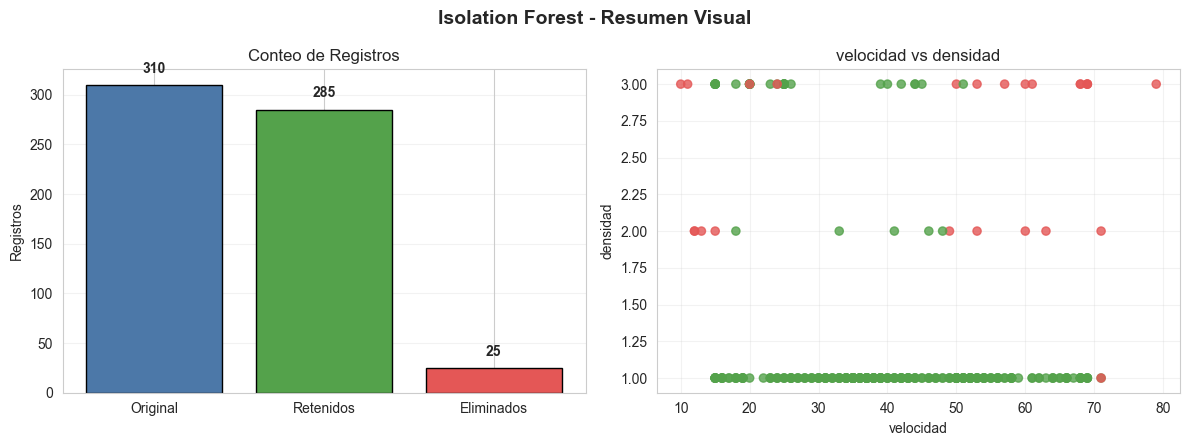

Visualización guardada


In [33]:
output_graph_dir = Path('../../data/03_algorithm_output')
output_graph_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Isolation Forest - Resumen Visual', fontsize=14, fontweight='bold')

labels = ['Original', 'Retenidos', 'Eliminados']
values = [len(df_result), retained, removed]
colors = ['#4C78A8', '#54A24B', '#E45756']
axes[0].bar(labels, values, color=colors, edgecolor='black')
axes[0].set_title('Conteo de Registros')
axes[0].set_ylabel('Registros')
axes[0].grid(axis='y', alpha=0.25)
for i, value in enumerate(values):
    axes[0].text(i, value + max(values) * 0.03, str(value), ha='center', va='bottom', fontweight='bold')

if len(features) >= 2:
    x_col, y_col = features[:2]
    colors_map = df_result['is_inlier'].map({True: '#54A24B', False: '#E45756'})
    axes[1].scatter(df_result[x_col], df_result[y_col], c=colors_map, alpha=0.8, s=35)
    axes[1].set_title(f'{x_col} vs {y_col}')
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel(y_col)
    axes[1].grid(alpha=0.25)
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'No hay suficientes variables para el scatter', ha='center', va='center')

plt.tight_layout()
plt.savefig(output_graph_dir / '11_isolation_forest_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('Visualización guardada')

## 8. Cierre
Los resultados exactos no son una meta por sí misma. La lectura correcta es que este dataset tiene estructura simple, nulos importantes en columnas contextuales y una señal limitada para outliers.

Si quieres una comparación más justa, el siguiente paso es contrastar Isolation Forest contra LOF y DBSCAN con la misma lógica de diagnóstico primero.

In [34]:
print('Notebook de Isolation Forest finalizado correctamente')

Notebook de Isolation Forest finalizado correctamente
